# Notebook 3 — Velocity gradient (Section 6.2) and Figures 7+8

This notebook

1. Fits the 8-parameter velocity-gradient model to the 21 Boötes III
   members (free $v_{\rm hel,0}$, $dV/d\alpha\cos\delta$, $dV/d\delta$,
   $\sigma_v$, $[\mathrm{Fe/H}]_0$, $\sigma_{[\mathrm{Fe/H}]}$,
   $\mu_{\alpha,0}\cos\delta$, $\mu_{\delta,0}$) using the same 2-D
   Gaussian PM likelihood as notebook 1 — but with a linear $v_{\rm los}$
   gradient on the sky.
2. Computes the **perspective-rotation prediction** (the apparent
   $v_{\rm los}$ gradient that arises purely from the Sun + progenitor
   PM if the system were a rigid body), and the **orbit prediction** for
   $dV/d\alpha\cos\delta, dV/d\delta$ using McMillan17 with the halo
   amplitude scaled by $f \in \{0.5, 0.75, 1.0, 1.25, 1.5\}$.
3. Loads the $10^6$ M$_\odot$ Boo III N-body simulation and computes the
   linear $v_{\rm los}$ gradient within 1 $r_h$ (with bootstrap 1$\sigma$).
4. Renders the 2$\times$2 Figure 7 and saves it to
   `figures/fig7_gradient_comparison.pdf`.

Standalone — no imports from `../code/`.


## 0 · Setup

In [1]:
import os, sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.stats as stats
from scipy.optimize import curve_fit

import h5py
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.transforms as _mt
import matplotlib.patheffects as mpe
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Ellipse, Circle

import astropy.units as u
import astropy.coordinates as acoo
from astropy.coordinates import SkyCoord, Galactocentric, ICRS

from galpy.orbit import Orbit
from galpy.potential import MWPotential2014
from galpy.potential import (
    ChandrasekharDynamicalFrictionForce, HernquistPotential,
    MovingObjectPotential, NonInertialFrameForce,
    evaluateRforces, evaluatephitorques, evaluatezforces,
)
import pickle
from galpy.potential.mwpotentials import McMillan17 as _McMillan17
from galpy.util.conversion import get_physical

# ---- Project paths ----
NB_DIR   = Path.cwd().resolve()
PROJ     = NB_DIR.parent
DATA_DIR = PROJ / "data"
OUT_DIR  = PROJ / "output"
FIG_DIR  = PROJ / "figures"

# 1e6 Msun N-body sim
SIM_PATH = DATA_DIR / "boo3_v1_1e6.0Msun_McMillan.h5"  # local copy

%matplotlib inline
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 300,
    "axes.labelsize": 14, "axes.titlesize": 15, "axes.linewidth": 1.2,
    "xtick.labelsize": 13, "ytick.labelsize": 13,
    "xtick.direction": "in", "ytick.direction": "in",
    "xtick.top": True, "ytick.right": True,
    "xtick.minor.visible": True, "ytick.minor.visible": True,
    "xtick.major.size": 5, "xtick.minor.size": 3,
    "ytick.major.size": 5, "ytick.minor.size": 3,
    "legend.fontsize": 12, "legend.frameon": False,
    "font.family": "serif", "mathtext.fontset": "cm",
})

print(f"Project root  : {PROJ}")
print(f"Sim file      : {SIM_PATH}")


Project root  : /Users/tingli/Dropbox/claude_research/boo3paper/paper_final_new6D_newSim
Sim file      : /Users/tingli/Dropbox/claude_research/boo3paper/paper_final_new6D_newSim/data/boo3_v1_1e6.0Msun_McMillan.h5


## 1 · Boötes III geometry constants


In [2]:
RA_BOO3   = 209.5567       # NEW ellipse-centroid (this work)
DEC_BOO3  = 26.5529
DIST_KPC  = 48.47           # NEW distance from RRL (Garofalo+22)
RHALF_CIRC_AM = 33.03
ELLIPTICITY   = 0.33
PA_DEG        = 278.91

RHALF_MAJOR_AM = RHALF_CIRC_AM / np.sqrt(1 - ELLIPTICITY)
RHALF_MAJOR_DEG = RHALF_MAJOR_AM / 60.0

# Astropy v4.0 solar motion (matches notebook 1 / 2)
SOLAR_MOTION = [-12.9, 12.5, 7.78]


## 2 · Inline helpers — perspective rotation, solar-reflex correction

`predict_perspective_rotation(ra0, dec0, dist0, pmra0, pmdec0, vrad0, ras, decs)`
returns the apparent (pmra, pmdec, vrad) at sky positions (ras, decs) of
stars assumed to share the same 6-D Galactocentric velocity as the
progenitor — i.e. the field of solid-body rotation seen as perspective
projection. This isolates the geometric "perspective rotation" component
of any apparent velocity gradient.

`correct_pm(ra, dec, pmra, pmdec, dist)` and `correct_vel(...)` subtract
the Sun's apparent motion (the solar-reflex correction) from heliocentric
PMs and RVs, returning the intrinsic (Galactocentric-rest-frame-relative)
quantities.

Both helpers are direct ports of the published S5 / GD-1 pipeline code,
inlined here so the notebook is self-contained.


In [3]:
# Galactocentric frame using astropy v4.0 default
GCPARAMS = acoo.galactocentric_frame_defaults.get_from_registry("v4.0")["parameters"]
k_masyr_kpc = 4.740470463498976  # (km/s) / (kpc * mas/yr)


def _get_apparent_solar_velocity_icrs(params):
    gc_rest = acoo.Galactocentric(
        x=0*u.kpc, y=0*u.kpc, z=0*u.kpc,
        v_x=0*u.km/u.s, v_y=0*u.km/u.s, v_z=0*u.km/u.s,
        **params)
    icrs_apparent = gc_rest.transform_to(ICRS())
    return icrs_apparent.velocity.d_xyz.to_value(u.km/u.s)


V_APPARENT_XYZ_ICRS = _get_apparent_solar_velocity_icrs(GCPARAMS)


def correct_pm(ra, dec, pmra, pmdec, dist):
    ra = np.atleast_1d(ra); dec = np.atleast_1d(dec)
    pmra = np.atleast_1d(pmra); pmdec = np.atleast_1d(pmdec)
    dist = np.atleast_1d(dist)
    if dist.size == 1 and ra.size > 1:
        dist = np.full_like(ra, dist.item())
    ra_r, dec_r = np.deg2rad(ra), np.deg2rad(dec)
    sin_ra, cos_ra = np.sin(ra_r), np.cos(ra_r)
    sin_dec, cos_dec = np.sin(dec_r), np.cos(dec_r)
    ra_hat  = np.stack([-sin_ra,         cos_ra,           np.zeros_like(sin_ra)], axis=0)
    dec_hat = np.stack([-sin_dec*cos_ra, -sin_dec*sin_ra,  cos_dec],               axis=0)
    v_ra  = np.dot(V_APPARENT_XYZ_ICRS, ra_hat)
    v_dec = np.dot(V_APPARENT_XYZ_ICRS, dec_hat)
    delta_pmra  = v_ra  / (dist * k_masyr_kpc)
    delta_pmdec = v_dec / (dist * k_masyr_kpc)
    pmra_c  = pmra  - delta_pmra
    pmdec_c = pmdec - delta_pmdec
    if pmra_c.size == 1:
        return float(pmra_c.item()), float(pmdec_c.item())
    return pmra_c, pmdec_c


def predict_perspective_rotation(ra0, dec0, dist0, pmra0, pmdec0, vrad0,
                                  ras, decs):
    # Project the progenitor's Galactocentric velocity vector back to the
    # heliocentric (pmra*cos delta, pmdec, vrad) at sky positions of the
    # other stars assuming they're all at the same physical location.
    kms, masyr = u.km/u.s, u.mas/u.yr
    C0 = SkyCoord(ra=ra0*u.deg, dec=dec0*u.deg, distance=dist0*u.kpc,
                  radial_velocity=vrad0*kms,
                  pm_ra_cosdec=pmra0*masyr, pm_dec=pmdec0*masyr)
    Cg0 = C0.transform_to(Galactocentric())
    sep_rad = C0.separation(SkyCoord(ra=ras*u.deg, dec=decs*u.deg)).to_value(u.rad)
    stardist = dist0 * np.cos(sep_rad) * u.kpc
    Cs1 = SkyCoord(ra=ras*u.deg, dec=decs*u.deg, distance=stardist)
    Cg1 = Cs1.transform_to(Galactocentric())
    Cg2 = Galactocentric(x=Cg1.x, y=Cg1.y, z=Cg1.z,
                          v_x=np.ones(len(ras))*Cg0.v_x,
                          v_y=np.ones(len(ras))*Cg0.v_y,
                          v_z=np.ones(len(ras))*Cg0.v_z)
    Cs2 = Cg2.transform_to(ICRS())
    return (Cs2.pm_ra_cosdec.to_value(masyr),
            Cs2.pm_dec.to_value(masyr),
            Cs2.radial_velocity.to_value(kms))


## 3 · v-gradient MCMC fit on the 21 high-prob members

8 parameters: $v_{\rm hel,0}$, $dV/d\alpha\cos\delta$, $dV/d\delta$,
$\sigma_v$, $[\mathrm{Fe/H}]_0$, $\sigma_{[\mathrm{Fe/H}]}$,
$\mu_{\alpha,0}\cos\delta$, $\mu_{\delta,0}$.

This is a direct fit on the members only — no mixture, no background.


In [4]:
# Load membership table from notebook 1
mem_csv = OUT_DIR / "boo3_gmm_membership.csv"
mem_all = pd.read_csv(mem_csv)
mem = mem_all[mem_all["p_mem"] > 0.8].copy().reset_index(drop=True)
print(f"members with p_mem > 0.8: {len(mem)}")
assert len(mem) == 21, f"Expected 21, got {len(mem)}"

VGRAD_PARAM_NAMES = [
    "vhel_0", "vhel_grad_E", "vhel_grad_N",
    "log_sig_vhel", "feh_0", "log_sig_feh", "pmr_0", "pmd_0",
]


# Priors mirror the previous pocoMC config (kind, args).  Combined Gaussian
# (vhel_0, feh_0, pmr_0, pmd_0) + uniform (everything else).
_PRIORS = [
    ("norm",  191.0, 10.0),
    ("uni",  -20.0,  20.0),    # vhel_grad_E in [-20, +20]
    ("uni",  -20.0,  20.0),    # vhel_grad_N
    ("uni",   -1.5,   1.3),    # log_sig_vhel
    ("norm",  -2.4,   1.0),
    ("uni",   -1.0,   0.3),
    ("norm", -1.17,   0.2),
    ("norm", -0.88,   0.2),
]


def _vgrad_log_prior(p):
    lp = 0.0
    for v, (kind, a, b) in zip(p, _PRIORS):
        if kind == "norm":
            lp += stats.norm.logpdf(v, loc=a, scale=b)
        else:
            if not (a <= v <= b):
                return -np.inf
    return lp


def _vgrad_log_likelihood_one(p, obs):
    p = p[None, :]
    vhel_0       = p[:, 0:1]
    vhel_gE      = p[:, 1:2]; vhel_gN = p[:, 2:3]
    log_sig_vhel = p[:, 3:4]
    feh_0        = p[:, 4:5]; log_sig_feh = p[:, 5:6]
    pmr_0        = p[:, 6:7]; pmd_0 = p[:, 7:8]
    sig_v   = 10 ** log_sig_vhel
    sig_feh = 10 ** log_sig_feh

    v   = obs["vel_calib"].values[None, :];      ve  = obs["vel_calib_std"].values[None, :]
    fe  = obs["feh50"].values[None, :];          fee = obs["feh_calib_std"].values[None, :]
    pa  = obs["pmra"].values[None, :];           pd_ = obs["pmdec"].values[None, :]
    sa  = obs["pmra_error"].values[None, :];     sd  = obs["pmdec_error"].values[None, :]
    rho = obs["pmra_pmdec_corr"].values[None, :]
    ra_d  = obs["ra_delta"].values[None, :]
    dec_d = obs["dec_delta"].values[None, :]

    vhel_pred = vhel_0 + vhel_gE * ra_d + vhel_gN * dec_d
    sv2  = ve**2 + sig_v**2
    ll_v = -0.5 * np.log(2*np.pi*sv2) - 0.5 * (v - vhel_pred)**2 / sv2

    sf2  = fee**2 + sig_feh**2
    ll_f = -0.5 * np.log(2*np.pi*sf2) - 0.5 * (fe - feh_0)**2 / sf2

    cov_xy = rho * sa * sd
    var_x  = sa**2; var_y = sd**2
    det    = var_x * var_y - cov_xy**2
    dx = pa - pmr_0; dy = pd_ - pmd_0
    quad = (dy**2 * var_x - 2 * dx * dy * cov_xy + dx**2 * var_y) / det
    ll_pm = -np.log(2*np.pi) - 0.5*np.log(det) - 0.5 * quad

    return float((ll_v + ll_f + ll_pm).sum())


def _vgrad_log_post(p, obs):
    lp = _vgrad_log_prior(p)
    if not np.isfinite(lp):
        return -np.inf
    ll = _vgrad_log_likelihood_one(p, obs)
    if not np.isfinite(ll):
        return -np.inf
    return lp + ll


import emcee, time as _time
N_WALKERS, N_STEPS, N_BURN = 64, 8000, 2000
_rng = np.random.default_rng(42)
_p0c = np.array([191.0, 0.0, 0.0, np.log10(1.0), -2.34, np.log10(0.3), -1.17, -0.88])
p0 = _p0c + 0.05 * np.array([10.0, 5.0, 5.0, 0.5, 0.5, 0.3, 0.05, 0.05]) * _rng.standard_normal((N_WALKERS, 8))

print(f"Running emcee v-gradient fit ({N_WALKERS} walkers x {N_STEPS} steps, 21 members) ...")
_t0 = _time.time()
_sampler = emcee.EnsembleSampler(N_WALKERS, 8, _vgrad_log_post, args=(mem,))
_sampler.run_mcmc(p0, N_STEPS, progress=False)
print(f"  emcee wall: {_time.time()-_t0:.1f} s,  acceptance: {np.mean(_sampler.acceptance_fraction):.3f}")

vgrad_samples = pd.DataFrame(
    _sampler.get_chain(discard=N_BURN, thin=10, flat=True),
    columns=VGRAD_PARAM_NAMES,
)
out_h5 = OUT_DIR / "boo3_21mem_vgrad_samples.h5"
vgrad_samples.to_hdf(out_h5, key="samples", mode="w")
print(f"posterior shape: {vgrad_samples.shape}  ->  {out_h5}")


members with p_mem > 0.8: 21
Running emcee v-gradient fit (64 walkers x 8000 steps, 21 members) ...


  emcee wall: 70.6 s,  acceptance: 0.457
posterior shape: (38400, 8)  ->  /Users/tingli/Dropbox/claude_research/boo3paper/paper_final_new6D_newSim/output/boo3_21mem_vgrad_samples.h5


In [5]:
# Posterior summary — focus on the gradient
def q1(arr):
    lo, med, hi = np.percentile(arr, [16, 50, 84])
    return med, hi - med, med - lo

print("v-gradient fit posterior (21 members):")
print(f"  v_hel       = {q1(vgrad_samples['vhel_0'].values)[0]:+8.3f} +{q1(vgrad_samples['vhel_0'].values)[1]:.3f}/-{q1(vgrad_samples['vhel_0'].values)[2]:.3f} km/s")
print(f"  dV/dalpha   = {q1(vgrad_samples['vhel_grad_E'].values)[0]:+8.3f} +{q1(vgrad_samples['vhel_grad_E'].values)[1]:.3f}/-{q1(vgrad_samples['vhel_grad_E'].values)[2]:.3f} km/s/deg")
print(f"  dV/ddelta   = {q1(vgrad_samples['vhel_grad_N'].values)[0]:+8.3f} +{q1(vgrad_samples['vhel_grad_N'].values)[1]:.3f}/-{q1(vgrad_samples['vhel_grad_N'].values)[2]:.3f} km/s/deg")
gmag = np.hypot(vgrad_samples["vhel_grad_E"].values,
                vgrad_samples["vhel_grad_N"].values)
pa = (np.degrees(np.arctan2(vgrad_samples["vhel_grad_E"].values,
                              vgrad_samples["vhel_grad_N"].values)) % 360)
print(f"  |grad|      = {np.median(gmag):.3f} km/s/deg")
print(f"  PA(grad)    = {np.median(pa):.1f} degrees (E of N)")
print(f"  sigma_v     = {q1(10**vgrad_samples['log_sig_vhel'].values)[0]:.3f} +{q1(10**vgrad_samples['log_sig_vhel'].values)[1]:.3f}/-{q1(10**vgrad_samples['log_sig_vhel'].values)[2]:.3f} km/s")

vhel_0_med = float(vgrad_samples['vhel_0'].median())
pmra_med   = float(vgrad_samples['pmr_0'].median())
pmdec_med  = float(vgrad_samples['pmd_0'].median())
gE_obs_med = float(vgrad_samples['vhel_grad_E'].median())
gN_obs_med = float(vgrad_samples['vhel_grad_N'].median())


v-gradient fit posterior (21 members):
  v_hel       = +191.225 +0.699/-0.754 km/s
  dV/dalpha   =   +0.550 +0.814/-0.813 km/s/deg
  dV/ddelta   =   -3.087 +1.962/-2.049 km/s/deg
  |grad|      = 3.260 km/s/deg
  PA(grad)    = 169.7 degrees (E of N)
  sigma_v     = 1.950 +0.817/-0.655 km/s


## 4 · Direction unit vectors for the gradient panel

* Apparent PM unit vector
* Solar-reflex-corrected (intrinsic) PM unit vector
* Galactic-Centre direction in the tangent plane at Boötes III


In [6]:
pm_app_unit = np.array([pmra_med, pmdec_med]) / max(np.hypot(pmra_med, pmdec_med), 1e-12)
pmra_corr_lit, pmdec_corr_lit = correct_pm(RA_BOO3, DEC_BOO3, pmra_med, pmdec_med, DIST_KPC)
pm_corr_unit = np.array([pmra_corr_lit, pmdec_corr_lit]) / max(np.hypot(pmra_corr_lit, pmdec_corr_lit), 1e-12)

# Galactic-Centre direction projected on the tangent plane at Boötes III
boo_icrs = SkyCoord(ra=RA_BOO3*u.deg, dec=DEC_BOO3*u.deg, distance=DIST_KPC*u.kpc)
boo_gc = boo_icrs.transform_to(Galactocentric())
xyz = np.array([boo_gc.x.to_value(u.kpc), boo_gc.y.to_value(u.kpc), boo_gc.z.to_value(u.kpc)])
unit_in = -xyz / np.linalg.norm(xyz)
xyz_step = xyz + 1.0 * unit_in
step_gc = SkyCoord(x=xyz_step[0]*u.kpc, y=xyz_step[1]*u.kpc, z=xyz_step[2]*u.kpc,
                   frame=Galactocentric(), representation_type="cartesian")
step_icrs = step_gc.transform_to(ICRS())
gc_dra  = (step_icrs.ra.deg  - RA_BOO3) * np.cos(np.radians(DEC_BOO3))
gc_ddec =  step_icrs.dec.deg - DEC_BOO3
gc_unit = np.array([gc_dra, gc_ddec]) / np.hypot(gc_dra, gc_ddec)

print(f"PA apparent PM   = {np.degrees(np.arctan2(*pm_app_unit)) % 360:6.2f} deg")
print(f"PA corrected PM  = {np.degrees(np.arctan2(*pm_corr_unit)) % 360:6.2f} deg")
print(f"PA Galactic Ctr  = {np.degrees(np.arctan2(*gc_unit)) % 360:6.2f} deg")


PA apparent PM   = 232.78 deg
PA corrected PM  = 257.37 deg
PA Galactic Ctr  = 131.49 deg


## 5 · Perspective-rotation gradient + Boötes III past orbit

The perspective-rotation prediction is built by computing the predicted
$v_{\rm los}$ at every member position assuming the system moves as a
solid body at the GMM-fit progenitor velocity. We then fit a linear
$v(\Delta\alpha\cos\delta, \Delta\delta)$ plane to those predictions and
read off $(dV/d\alpha\cos\delta, dV/d\delta)_{\rm persp}$. The 1$\sigma$
uncertainty is taken by repeating the calculation for 2000 posterior
draws of $(v_{\rm hel,0}, \mu_{\alpha,0}, \mu_{\delta,0})$ from the
v-gradient MCMC.


In [7]:
# Past orbit (cyan curve, MWPotential2014, 0.5 Gyr backward)
o = Orbit([RA_BOO3, DEC_BOO3, DIST_KPC, pmra_med, pmdec_med, vhel_0_med], radec=True)
ts_past = np.linspace(0.0, -0.5, 400) * u.Gyr
o.integrate(ts_past, MWPotential2014)
orbit_dra_arc  = (o.ra(ts_past)  - RA_BOO3) * np.cos(np.radians(DEC_BOO3)) * 60.0
orbit_ddec_arc =  (o.dec(ts_past) - DEC_BOO3) * 60.0


# Perspective gradient over 2000 posterior draws
print("Computing perspective-rotation gradient over 2000 posterior draws ...")
dra_obs  = mem["ra_delta"].values
ddec_obs = mem["dec_delta"].values
A_lsq = np.vstack([np.ones_like(dra_obs), dra_obs, ddec_obs]).T
rng = np.random.default_rng(42)
idx = rng.choice(len(vgrad_samples), size=min(2000, len(vgrad_samples)), replace=False)
gE_persp_arr = np.empty(idx.size); gN_persp_arr = np.empty(idx.size)
for k, i in enumerate(idx):
    _, _, vp = predict_perspective_rotation(
        ra0=RA_BOO3, dec0=DEC_BOO3, dist0=DIST_KPC,
        pmra0=float(vgrad_samples["pmr_0"].iloc[i]),
        pmdec0=float(vgrad_samples["pmd_0"].iloc[i]),
        vrad0=float(vgrad_samples["vhel_0"].iloc[i]),
        ras=mem["ra"].values, decs=mem["dec"].values,
    )
    coef, *_ = np.linalg.lstsq(A_lsq, vp, rcond=None)
    gE_persp_arr[k] = coef[1]; gN_persp_arr[k] = coef[2]

print(f"  gE_persp = {np.median(gE_persp_arr):+.3f} +{np.percentile(gE_persp_arr,84)-np.median(gE_persp_arr):.3f}/-{np.median(gE_persp_arr)-np.percentile(gE_persp_arr,16):.3f}")
print(f"  gN_persp = {np.median(gN_persp_arr):+.3f} +{np.percentile(gN_persp_arr,84)-np.median(gN_persp_arr):.3f}/-{np.median(gN_persp_arr)-np.percentile(gN_persp_arr,16):.3f}")

# For the perspective median in the sky-panel arrow scaling
_, _, vrad_pred_med = predict_perspective_rotation(
    ra0=RA_BOO3, dec0=DEC_BOO3, dist0=DIST_KPC,
    pmra0=pmra_med, pmdec0=pmdec_med, vrad0=vhel_0_med,
    ras=mem["ra"].values, decs=mem["dec"].values,
)
coef, *_ = np.linalg.lstsq(A_lsq, vrad_pred_med, rcond=None)
gE_pred_med, gN_pred_med = float(coef[1]), float(coef[2])
mem["vel_pred"] = vrad_pred_med


Computing perspective-rotation gradient over 2000 posterior draws ...


  gE_persp = -4.635 +0.063/-0.070
  gN_persp = -3.569 +0.050/-0.050


## 6 · Orbit prediction — McMillan17 with halo-mass scaling sweep

For each $f \in \{0.5, 0.75, 1.0, 1.25, 1.5\}$, scale the McMillan17 NFW
halo amplitude by $f$ and integrate the Boo III orbit ±0.2 Gyr. Compute
$v_{\rm los}$ at $\pm 1°$ along the orbit and form the local
$(dV/d\alpha\cos\delta, dV/d\delta)$ slope.


In [8]:
def compute_orbit_gradient(mw_factor, t_max_Myr=200.0, n_each=4001):
    pot_scaled = [p for p in _McMillan17]
    pot_scaled[1] = pot_scaled[1] * mw_factor
    PHYS = get_physical(_McMillan17); ro, vo = PHYS["ro"], PHYS["vo"]
    o_p = Orbit([RA_BOO3, DEC_BOO3, DIST_KPC, pmra_med, pmdec_med, vhel_0_med],
                radec=True, ro=ro, vo=vo)
    o_f = Orbit([RA_BOO3, DEC_BOO3, DIST_KPC, pmra_med, pmdec_med, vhel_0_med],
                radec=True, ro=ro, vo=vo)
    ts_p = np.linspace(0.0, -t_max_Myr * 1e-3, n_each) * u.Gyr
    ts_f = np.linspace(0.0,  t_max_Myr * 1e-3, n_each) * u.Gyr
    o_p.integrate(ts_p, pot_scaled); o_f.integrate(ts_f, pot_scaled)
    ra_a  = np.concatenate([o_p.ra(ts_p)[::-1],  o_f.ra(ts_f)[1:]])
    dec_a = np.concatenate([o_p.dec(ts_p)[::-1], o_f.dec(ts_f)[1:]])
    v_a   = np.concatenate([o_p.vlos(ts_p)[::-1], o_f.vlos(ts_f)[1:]])
    i0 = n_each - 1
    seg = np.degrees(np.arccos(np.clip(
        np.sin(np.radians(dec_a[:-1]))*np.sin(np.radians(dec_a[1:]))
        + np.cos(np.radians(dec_a[:-1]))*np.cos(np.radians(dec_a[1:]))
        * np.cos(np.radians(ra_a[:-1] - ra_a[1:])), -1.0, 1.0)))
    arc = np.concatenate([[0.0], np.cumsum(seg)]) - np.concatenate([[0.0], np.cumsum(seg)])[i0]
    v_p1 = float(np.interp(+1.0, arc, v_a))
    v_m1 = float(np.interp(-1.0, arc, v_a))
    slope = (v_p1 - v_m1) / 2.0
    dra_t  = (ra_a[i0+1]  - ra_a[i0-1])  * np.cos(np.radians(DEC_BOO3))
    ddec_t = (dec_a[i0+1] - dec_a[i0-1])
    pa_orbit = np.degrees(np.arctan2(dra_t, ddec_t)) % 360.0
    return dict(gE=slope * np.sin(np.radians(pa_orbit)),
                gN=slope * np.cos(np.radians(pa_orbit)),
                slope=slope, pa=pa_orbit)


MW_MASS_FACTORS = [0.5, 0.75, 1.0, 1.25, 1.5]
print("Computing orbit gradient for each McMillan17 halo-mass factor ...")
orbit_results = []
for f in MW_MASS_FACTORS:
    r = compute_orbit_gradient(f)
    orbit_results.append((f, r))
    print(f"  f={f:5.2f}: gE={r['gE']:+7.3f}, gN={r['gN']:+7.3f}")


Computing orbit gradient for each McMillan17 halo-mass factor ...


  f= 0.50: gE= -1.200, gN= -0.255


  f= 0.75: gE= +0.325, gN= +0.069


  f= 1.00: gE= +1.850, gN= +0.393


  f= 1.25: gE= +3.376, gN= +0.716


  f= 1.50: gE= +4.901, gN= +1.040


In [9]:
# (added) Recompute orbit_results in the McMillan17 + LMC potential, and
# compute the 3 spray-particle 2-D fits (0<r<2 deg) for the new Fig 7 markers.
SOLAR_MOTION_FID = [-12.9, 12.5, 7.78]


def _build_lmc_potential(mw_factor=1.0, solar_motion=SOLAR_MOTION_FID):
    base = [pp for pp in _McMillan17]
    base[1] = base[1] * mw_factor
    mass_lmc = 1.38e11; rscale = 16.09; rhm = rscale * (1 + np.sqrt(2))
    orb_lmc = Orbit.from_name("LMC", solarmotion=solar_motion, **get_physical(base))
    cdf = ChandrasekharDynamicalFrictionForce(GMs=mass_lmc * u.Msun, rhm=rhm * u.kpc,
                                              dens=base[1], **get_physical(base))
    orb_lmc.integrate(-np.linspace(0, 5, 1001) * u.Gyr, base + [cdf])
    lmcpot = HernquistPotential(amp=2 * mass_lmc * u.Msun, a=rscale * u.kpc, **get_physical(base))
    moving = MovingObjectPotential(orb_lmc, pot=lmcpot, **get_physical(base))
    loc = 1e-4
    af = lambda t: evaluateRforces(moving, loc, 0., phi=0., t=t, use_physical=False)
    bf = lambda t: evaluatephitorques(moving, loc, 0., phi=0., t=t, use_physical=False) / loc
    cf = lambda t: evaluatezforces(moving, loc, 0., phi=0., t=t, use_physical=False)
    ti = orb_lmc.time(use_physical=False)[::-1]
    aa = np.array([af(t) for t in ti]); ab = np.array([bf(t) for t in ti]); ac = np.array([cf(t) for t in ti])
    nip = NonInertialFrameForce(a0=[lambda t: np.interp(t, ti, aa),
                                     lambda t: np.interp(t, ti, ab),
                                     lambda t: np.interp(t, ti, ac)])
    return base + [nip, moving], base


def _orbit_gradient_with_lmc(mw_factor, t_max_Myr=200.0, n_each=4001):
    pot, _ = _build_lmc_potential(mw_factor)
    PHYS = get_physical(_McMillan17); ro, vo = PHYS["ro"], PHYS["vo"]
    o_p = Orbit([RA_BOO3, DEC_BOO3, DIST_KPC, pmra_med, pmdec_med, vhel_0_med],
                radec=True, solarmotion=SOLAR_MOTION_FID, ro=ro, vo=vo)
    o_f = Orbit([RA_BOO3, DEC_BOO3, DIST_KPC, pmra_med, pmdec_med, vhel_0_med],
                radec=True, solarmotion=SOLAR_MOTION_FID, ro=ro, vo=vo)
    ts_p = np.linspace(0.0, -t_max_Myr * 1e-3, n_each) * u.Gyr
    ts_f = np.linspace(0.0,  t_max_Myr * 1e-3, n_each) * u.Gyr
    o_p.integrate(ts_p, pot); o_f.integrate(ts_f, pot)
    ra_a  = np.concatenate([o_p.ra(ts_p)[::-1],  o_f.ra(ts_f)[1:]])
    dec_a = np.concatenate([o_p.dec(ts_p)[::-1], o_f.dec(ts_f)[1:]])
    v_a   = np.concatenate([o_p.vlos(ts_p)[::-1], o_f.vlos(ts_f)[1:]])
    i0 = n_each - 1
    seg = np.degrees(np.arccos(np.clip(
        np.sin(np.radians(dec_a[:-1]))*np.sin(np.radians(dec_a[1:]))
        + np.cos(np.radians(dec_a[:-1]))*np.cos(np.radians(dec_a[1:]))
        * np.cos(np.radians(ra_a[:-1] - ra_a[1:])), -1.0, 1.0)))
    arc = np.concatenate([[0.0], np.cumsum(seg)]); arc = arc - arc[i0]
    v_p1 = float(np.interp(+1.0, arc, v_a))
    v_m1 = float(np.interp(-1.0, arc, v_a))
    slope = (v_p1 - v_m1) / 2.0
    dra_t  = (ra_a[i0+1] - ra_a[i0-1]) * np.cos(np.radians(dec_a[i0]))
    ddec_t = (dec_a[i0+1] - dec_a[i0-1])
    pa_orbit = np.degrees(np.arctan2(dra_t, ddec_t)) % 360.0
    return dict(gE=slope * np.sin(np.radians(pa_orbit)),
                gN=slope * np.cos(np.radians(pa_orbit)),
                slope=slope, pa=pa_orbit)


print("Recomputing orbit gradient (McMillan17 + LMC) for f = 0.5, 0.75, 1.0, 1.25, 1.5 ...")
orbit_results = []  # override the no-LMC result from the previous cell
for f in MW_MASS_FACTORS:
    r = _orbit_gradient_with_lmc(f)
    orbit_results.append((f, r))
    print(f"  f={f:5.2f}:  gE={r['gE']:+7.3f}  gN={r['gN']:+7.3f}  |g|={np.hypot(r['gE'], r['gN']):.2f}  PA={r['pa']:.2f}")


# --- 6D MC 1000-realisation summary for the f=1 with-LMC orbit error bar ---
# Load the 1000-realisation 6D MC produced by nb01 (with new 6D + 0.3 deg RA/Dec + 2.2 kpc dist).
_mc = np.load(OUT_DIR / "orbit_gradient_mc_1000_summary.npz", allow_pickle=True)
MC_gE_pct = np.nanpercentile(_mc["gE"], [16, 50, 84])
MC_gN_pct = np.nanpercentile(_mc["gN"], [16, 50, 84])
print(f"\nMC 6D 1-sigma on f=1 (with LMC):")
print(f"  gE = {MC_gE_pct[1]:+.3f}  [16,84] = [{MC_gE_pct[0]:+.3f}, {MC_gE_pct[2]:+.3f}]")
print(f"  gN = {MC_gN_pct[1]:+.3f}  [16,84] = [{MC_gN_pct[0]:+.3f}, {MC_gN_pct[2]:+.3f}]")


Recomputing orbit gradient (McMillan17 + LMC) for f = 0.5, 0.75, 1.0, 1.25, 1.5 ...


  f= 0.50:  gE= -1.529  gN= -0.343  |g|=1.57  PA=257.37


  f= 0.75:  gE= +0.009  gN= +0.002  |g|=0.01  PA=257.37


  f= 1.00:  gE= +1.547  gN= +0.347  |g|=1.59  PA=257.37


  f= 1.25:  gE= +3.085  gN= +0.691  |g|=3.16  PA=257.37


  f= 1.50:  gE= +4.623  gN= +1.036  |g|=4.74  PA=257.37

MC 6D 1-sigma on f=1 (with LMC):
  gE = +1.574  [16,84] = [+0.516, +2.758]
  gN = +0.316  [16,84] = [+0.129, +0.462]


## 7 · Load 1e6 Msun N-body sim, fit Plummer, cut to 1 r_h

Computes the linear $v_{\rm los}$ gradient inside $1\,r_h$ via an
ordinary-least-squares fit + 2000 bootstrap resamples for the 1$\sigma$
on $(gE, gN)$.


In [10]:
print(f"Loading 1e6 Msun sim from {SIM_PATH} ...")
with h5py.File(SIM_PATH, "r") as h:
    ra_s   = h["ra"][:]
    dec_s  = h["dec"][:]
    vlsr_s = h["vhel"][:]    # new sim uses "vhel" key (= heliocentric v_los)
# Wrap RA into (RA_BOO3 - 180, RA_BOO3 + 180]; new sim stores raw [-180, 180]
ra_s = ((ra_s - RA_BOO3 + 180) % 360) - 180 + RA_BOO3
print(f"  N particles: {len(ra_s):,}")


def plummer(r, S0, rh):
    return S0 / (1 + (r/rh)**2)**2


def fit_plummer(ra, dec, ra0, dec0, max_r=3.0, fit_max_r=1.5, n_bins=50):
    dra = (ra - ra0) * np.cos(np.radians(dec0)); ddec = dec - dec0
    r = np.sqrt(dra**2 + ddec**2)
    edges = np.linspace(0, max_r, n_bins + 1)
    counts, _ = np.histogram(r[r < max_r], bins=edges)
    rmid = 0.5 * (edges[1:] + edges[:-1])
    area = np.pi * (edges[1:]**2 - edges[:-1]**2)
    sig = counts / area
    fit_mask = (counts > 0) & (rmid < fit_max_r)
    popt, _ = curve_fit(plummer, rmid[fit_mask], sig[fit_mask],
                        p0=[sig[fit_mask].max(), 0.5],
                        sigma=np.sqrt(counts[fit_mask]) / area[fit_mask])
    return popt


cra_s, cdec_s = RA_BOO3, DEC_BOO3
popt = fit_plummer(ra_s, dec_s, cra_s, cdec_s)
rh_sim = popt[1]
print(f"  sim center : ({cra_s:.3f}, {cdec_s:.3f})  r_h(sim) = {rh_sim*60:.2f} arcmin")

dra_full  = (ra_s - cra_s) * np.cos(np.radians(cdec_s))
ddec_full =  dec_s - cdec_s
r_sky = np.hypot(dra_full, ddec_full)
r_cut = 2.0 * RHALF_CIRC_AM / 60.0  # 2 r_h around the literature r_h (Section 6.2)
inside = r_sky < r_cut
dra_in  = dra_full[inside]
ddec_in = ddec_full[inside]
v_in    = vlsr_s[inside]
print(f"  particles inside 2 r_h ({r_cut*60:.2f}'): {inside.sum():,}")


def fit_grad_lsq(dra_deg, ddec_deg, v):
    A = np.vstack([np.ones_like(dra_deg), dra_deg, ddec_deg]).T
    coef, *_ = np.linalg.lstsq(A, v, rcond=None)
    return float(coef[0]), float(coef[1]), float(coef[2])


def bootstrap_grad(dra_deg, ddec_deg, v, n=2000, rng=None):
    rng = rng or np.random.default_rng(42)
    out = np.empty((n, 2)); N = len(v)
    for i in range(n):
        ix = rng.integers(0, N, N)
        _, gE, gN = fit_grad_lsq(dra_deg[ix], ddec_deg[ix], v[ix])
        out[i, 0] = gE; out[i, 1] = gN
    return out


_, gE_sim, gN_sim = fit_grad_lsq(dra_in, ddec_in, v_in)
mag_sim = float(np.hypot(gE_sim, gN_sim))
pa_sim  = float(np.degrees(np.arctan2(gE_sim, gN_sim)) % 360.0)
print(f"  sim gradient (LSQ): gE={gE_sim:+.3f}, gN={gN_sim:+.3f}, |g|={mag_sim:.3f}, PA={pa_sim:.1f}")

print("  bootstrapping (n=2000) ...")
boot_sim = bootstrap_grad(dra_in, ddec_in, v_in, n=2000)
gE_sim_med = float(np.median(boot_sim[:, 0]))
gN_sim_med = float(np.median(boot_sim[:, 1]))
gE_sim_lo  = gE_sim_med - float(np.percentile(boot_sim[:, 0], 16))
gE_sim_hi  = float(np.percentile(boot_sim[:, 0], 84)) - gE_sim_med
gN_sim_lo  = gN_sim_med - float(np.percentile(boot_sim[:, 1], 16))
gN_sim_hi  = float(np.percentile(boot_sim[:, 1], 84)) - gN_sim_med
print(f"  bootstrap : gE = {gE_sim_med:+.3f} -{gE_sim_lo:.3f}/+{gE_sim_hi:.3f}")
print(f"             gN = {gN_sim_med:+.3f} -{gN_sim_lo:.3f}/+{gN_sim_hi:.3f}")


Loading 1e6 Msun sim from /Users/tingli/Dropbox/claude_research/boo3paper/paper_final_new6D_newSim/data/boo3_v1_1e6.0Msun_McMillan.h5 ...
  N particles: 1,000,000
  sim center : (209.557, 26.553)  r_h(sim) = 78.56 arcmin
  particles inside 2 r_h (66.06'): 123,201
  sim gradient (LSQ): gE=+1.614, gN=-1.025, |g|=1.912, PA=122.4
  bootstrapping (n=2000) ...


  bootstrap : gE = +1.614 -0.010/+0.011
             gN = -1.025 -0.012/+0.012


## 8 · Figure 7 — 2 x 2 master plot

Top-left: S5 sky panel with PM (apparent), PM (intrinsic), Galactic
Centre direction arrows + observed v-gradient arrow + 1$\sigma$ ellipse
+ past orbit + half-light ellipses.

Top-right: gradient comparison with markers for observed (yellow, with
1$\sigma$ from MCMC), solid-body / perspective (red), McMillan17 mass
sweep (diamonds, viridis-r colourmap), and 1e6 sim (cyan triangle).

Bottom-left: sim mean $v_{\rm los}$ map within 1 $r_h$ + cyan grad arrow.
Bottom-right: sim $\sigma_v$ dispersion map within 1 $r_h$.


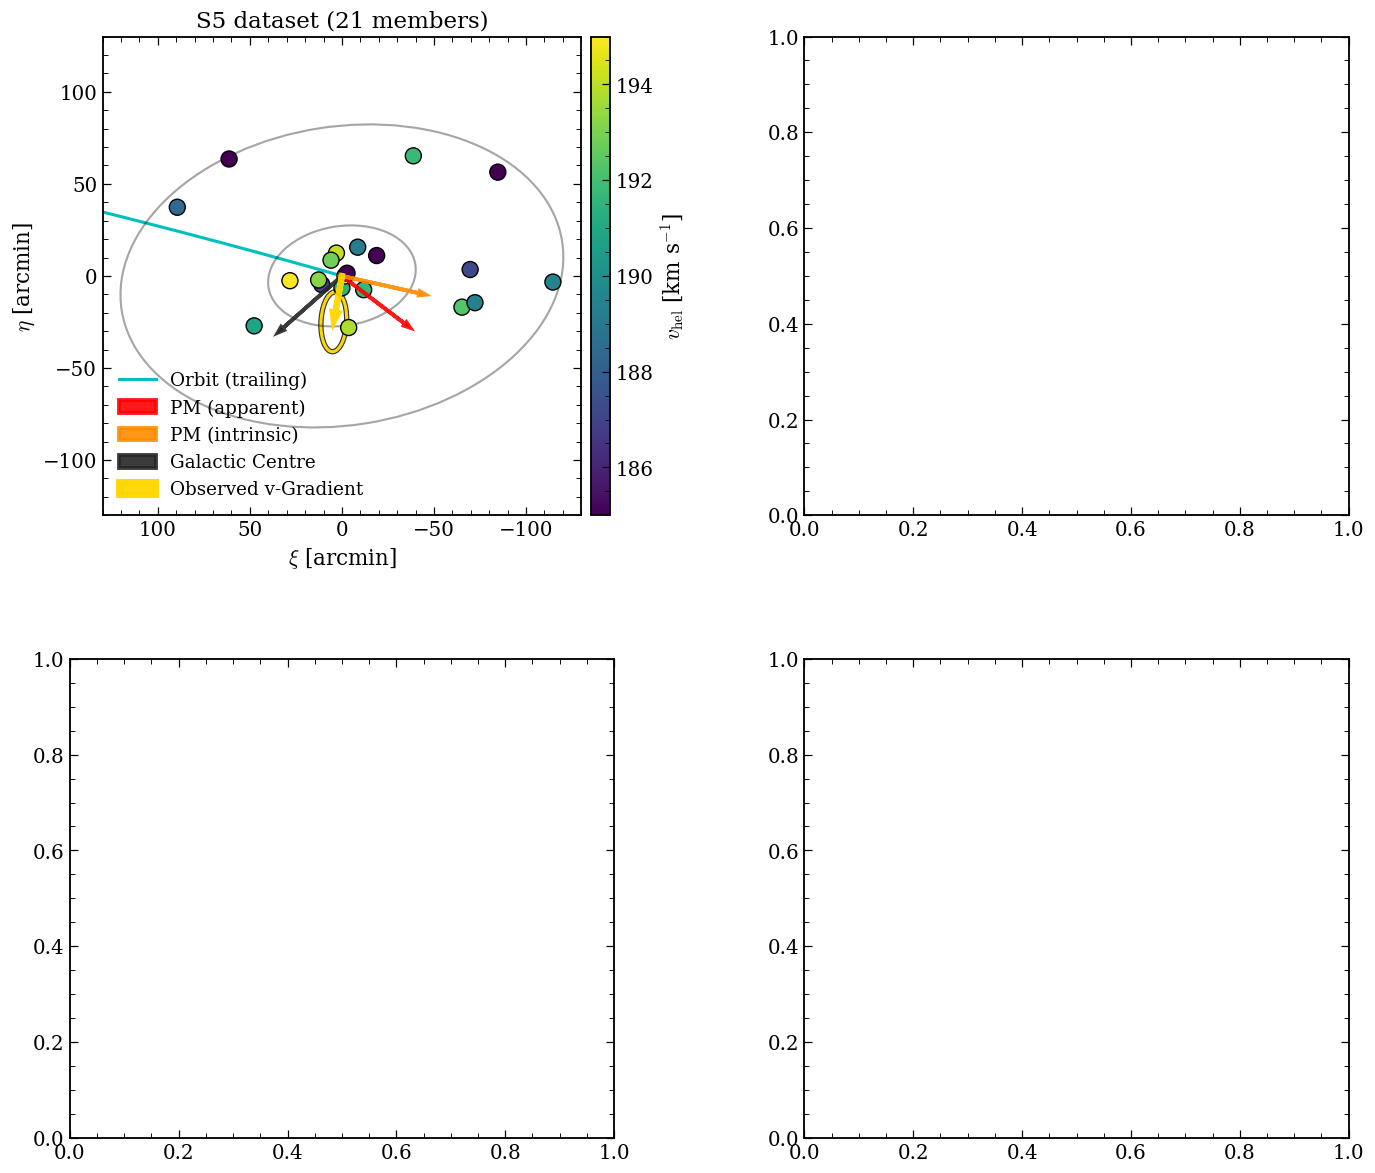

In [11]:
def confidence_ellipse(x, y, ax, n_std=1.0, **kwargs):
    cov = np.cov(x, y)
    pearson = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])
    ell_rx = np.sqrt(1 + pearson); ell_ry = np.sqrt(1 - pearson)
    ell = Ellipse((0, 0), width=ell_rx*2, height=ell_ry*2, facecolor="none", **kwargs)
    sx = np.sqrt(cov[0, 0]) * n_std; sy = np.sqrt(cov[1, 1]) * n_std
    transf = (_mt.Affine2D().rotate_deg(45).scale(sx, sy)
              .translate(np.mean(x), np.mean(y)))
    ell.set_transform(transf + ax.transData)
    return ax.add_patch(ell)


def grad_arrow(ax, gE, gN, mag, color, label_text, len_norm=0.7, extent=1.0,
               fontsize=13, label_offset_perp=0.12, label_along=0.80, zorder=5):
    if mag <= 0: return
    u_ = np.array([gE, gN]) / mag
    perp = np.array([-u_[1], u_[0]])
    L = len_norm * extent
    ax.annotate("", xy=(L * u_[0], L * u_[1]), xytext=(0, 0),
                arrowprops=dict(arrowstyle="-|>", color=color, lw=2.6,
                                mutation_scale=18), zorder=zorder)
    lpos = label_along * L * u_ + label_offset_perp * extent * perp
    ax.text(lpos[0], lpos[1], label_text, color=color, fontsize=fontsize,
            fontweight="bold", ha="center", va="center",
            path_effects=[mpe.withStroke(linewidth=3.0, foreground="white")],
            zorder=zorder + 1)


PM_COLOR = "red"; OBS_COLOR = "gold"; SIM_COLOR = "cyan"
SKY_VCMAP = mpl.colormaps.get_cmap("viridis")
ORBIT_CMAP = "viridis_r"

fig = plt.figure(figsize=(15, 13))
gs = GridSpec(2, 2, figure=fig, wspace=0.35, hspace=0.30)
ax_sky  = fig.add_subplot(gs[0, 0])
ax_grad = fig.add_subplot(gs[0, 1])
ax_simv = fig.add_subplot(gs[1, 0])
ax_simd = fig.add_subplot(gs[1, 1])


# ============ TOP-LEFT: S5 sky ============
ax_sky.set_title("S5 dataset (21 members)")
vmin, vmax = 185, 195
mem_dra_a  = mem["ra_delta"].values  * 60.0
mem_ddec_a = mem["dec_delta"].values * 60.0

sc1 = ax_sky.scatter(mem_dra_a, mem_ddec_a, c=mem["vel_calib"], cmap=SKY_VCMAP,
                      vmin=vmin, vmax=vmax, ec="k", s=110, lw=0.9, zorder=6)
ax_sky.plot(orbit_dra_arc, orbit_ddec_arc, color="c", lw=2, label="Orbit (trailing)")

VS_ARCMIN_PER_KMS_DEG = 25.0 / max(np.hypot(gE_obs_med, gN_obs_med), 1.0)
pm_mag = np.hypot(pmra_med, pmdec_med)
mag_per = float(np.hypot(gE_pred_med, gN_pred_med))
persp_arrow_len = mag_per * VS_ARCMIN_PER_KMS_DEG
VS_PM = persp_arrow_len / max(pm_mag, 1e-6)

# Apparent PM arrow (red - matches solid-body color on the gradient panel)
ax_sky.arrow(0, 0, pmra_med * VS_PM, pmdec_med * VS_PM,
             head_width=2.4, length_includes_head=True, lw=2.5,
             color=PM_COLOR, alpha=0.9, zorder=10, label="PM (apparent)")
# Solar-reflex-corrected (intrinsic) PM direction
L_DIR_SKY = pm_mag * VS_PM
ax_sky.arrow(0, 0, pm_corr_unit[0] * L_DIR_SKY, pm_corr_unit[1] * L_DIR_SKY,
             head_width=2.4, length_includes_head=True, lw=2.5,
             color="darkorange", alpha=0.9, zorder=10, label="PM (intrinsic)")
# Galactic-Centre direction
ax_sky.arrow(0, 0, gc_unit[0] * L_DIR_SKY, gc_unit[1] * L_DIR_SKY,
             head_width=2.4, length_includes_head=True, lw=2.5,
             color="0.15", alpha=0.9, zorder=10, label="Galactic Centre")
# Observed v-gradient (yellow)
ax_sky.arrow(0, 0, gE_obs_med * VS_ARCMIN_PER_KMS_DEG,
             gN_obs_med * VS_ARCMIN_PER_KMS_DEG,
             head_width=3.2, length_includes_head=True, lw=4,
             color=OBS_COLOR, alpha=0.95, zorder=11, label="Observed v-Gradient")

obs_samples = np.column_stack([vgrad_samples["vhel_grad_E"].values,
                                vgrad_samples["vhel_grad_N"].values])
confidence_ellipse(obs_samples[:, 0]*VS_ARCMIN_PER_KMS_DEG,
                   obs_samples[:, 1]*VS_ARCMIN_PER_KMS_DEG,
                   ax_sky, n_std=1.0, ec=OBS_COLOR, lw=2,
                   path_effects=[mpe.withStroke(linewidth=3.5, foreground="0.2")])

rh_a = RHALF_CIRC_AM
for n in (1, 3):
    ax_sky.add_patch(Ellipse(xy=(0, 0),
                              width=2*n*rh_a/np.sqrt(1 - ELLIPTICITY),
                              height=2*n*rh_a*np.sqrt(1 - ELLIPTICITY),
                              angle=90 - PA_DEG,
                              fc="none", ec="k", lw=1.4, alpha=0.35, zorder=4))
extent = 130
ax_sky.set_xlim(extent, -extent); ax_sky.set_ylim(-extent, extent)
ax_sky.set_aspect("equal", adjustable="box")
ax_sky.set_xlabel(r"$\xi$ [arcmin]")
ax_sky.set_ylabel(r"$\eta$ [arcmin]")
ax_sky.legend(loc="lower left",  fontsize=12, framealpha=0.92)
cax_sky = ax_sky.inset_axes([1.02, 0.0, 0.04, 1.0])
cb_sky = fig.colorbar(sc1, cax=cax_sky)
cb_sky.set_label(r"$v_{\rm hel}$ [km s$^{-1}$]", fontsize=14)


In [12]:
# ============ TOP-RIGHT: gradient comparison ============
ax_grad.set_title("Gradient comparison")
ax_grad.axhline(0, c="0.6", lw=0.7, zorder=0)
ax_grad.axvline(0, c="0.6", lw=0.7, zorder=0)


def median_with_1sigma(arr):
    med = float(np.median(arr))
    lo  = med - float(np.percentile(arr, 16))
    hi  = float(np.percentile(arr, 84)) - med
    return med, lo, hi


gE_obs,    gE_obs_lo,    gE_obs_hi    = median_with_1sigma(vgrad_samples["vhel_grad_E"].values)
gN_obs,    gN_obs_lo,    gN_obs_hi    = median_with_1sigma(vgrad_samples["vhel_grad_N"].values)
gE_persp,  gE_persp_lo,  gE_persp_hi  = median_with_1sigma(gE_persp_arr)
gN_persp,  gN_persp_lo,  gN_persp_hi  = median_with_1sigma(gN_persp_arr)

ax_grad.errorbar([gE_obs], [gN_obs],
                 xerr=[[gE_obs_lo], [gE_obs_hi]], yerr=[[gN_obs_lo], [gN_obs_hi]],
                 fmt="o", ms=9, c=OBS_COLOR, mec="k", mew=0.8, lw=1.6, capsize=4,
                 label="Observed (S5 21-mem MCMC)", zorder=10)
ax_grad.errorbar([gE_persp], [gN_persp],
                 xerr=[[gE_persp_lo], [gE_persp_hi]],
                 yerr=[[gN_persp_lo], [gN_persp_hi]],
                 fmt="s", ms=9, c=PM_COLOR, mec="k", mew=0.8, lw=1.6, capsize=4,
                 label="Solid-body (perspective)", zorder=10)

gE_orb = np.array([r["gE"] for f, r in orbit_results])
gN_orb = np.array([r["gN"] for f, r in orbit_results])
factors = np.array([f for f, r in orbit_results])
norm = plt.Normalize(vmin=factors.min(), vmax=factors.max())
cmap_o = mpl.colormaps.get_cmap(ORBIT_CMAP)
ax_grad.plot(gE_orb, gN_orb, "-", c="0.4", lw=1.0, alpha=0.6, zorder=4)
sc_o = ax_grad.scatter(gE_orb, gN_orb, c=factors, cmap=cmap_o, norm=norm,
                       s=85, marker="D", ec="k", lw=0.7, zorder=5,
                       label=r"Orbit (McM17 + LMC, halo $\times f$)")
# Diamonds annotate ABOVE the marker; spray stars annotate BELOW.
for f, r in orbit_results:
    ax_grad.annotate(f"{f:g}", (r["gE"], r["gN"]), textcoords="offset points",
                      xytext=(0, 9), fontsize=11, color="0.2", fontweight="bold",
                      ha="center", zorder=15)

# 6D MC 1-sigma error bar on the f=1 with-LMC orbit diamond
_gE_f1 = next(rr["gE"] for ff, rr in orbit_results if ff == 1.0)
_gN_f1 = next(rr["gN"] for ff, rr in orbit_results if ff == 1.0)
_xerr = np.array([[MC_gE_pct[1] - MC_gE_pct[0]], [MC_gE_pct[2] - MC_gE_pct[1]]])
_yerr = np.array([[MC_gN_pct[1] - MC_gN_pct[0]], [MC_gN_pct[2] - MC_gN_pct[1]]])
# 6D MC error bar drawn on a back layer (zorder=1) so it doesn't sit
# on top of the diamond/star/observation symbols.
ax_grad.errorbar(_gE_f1, _gN_f1, xerr=_xerr, yerr=_yerr,
                 fmt="none", ecolor="0.4",
                 elinewidth=1.4, capsize=4, alpha=0.85, zorder=1,
                 label=r"6D MC 1$\sigma$ (fid potential)")
# Sim point: bootstrap errors are ~0.02, invisible at marker size
ax_grad.plot([gE_sim_med], [gN_sim_med], marker="^", ms=10,
             mfc=SIM_COLOR, mec="k", mew=0.7, ls="",
             label=r"$10^6\,$M$_\odot$ sim", zorder=10)

ax_grad.set_xlim(8.0, -6.0); ax_grad.set_ylim(-6.0, 8.0)
ax_grad.set_aspect("equal", adjustable="box")
ax_grad.set_xlabel(r"$\partial v_{\rm los}/\partial\xi$ [km s$^{-1}$ deg$^{-1}$]")
ax_grad.set_ylabel(r"$\partial v_{\rm los}/\partial\eta$ [km s$^{-1}$ deg$^{-1}$]")
ax_grad.legend(loc="upper right", fontsize=12, framealpha=0.95)
ax_grad.grid(alpha=0.3)
cbar_o_ax = ax_grad.inset_axes([1.02, 0.0, 0.04, 1.0])
cb_o = fig.colorbar(sc_o, cax=cbar_o_ax)
cb_o.set_label("MW halo factor", fontsize=14)


In [13]:
# ============ BOTTOM-LEFT: sim mean v_los ============
dra_in_arc  = dra_in  * 60.0
ddec_in_arc = ddec_in * 60.0
extent_sim = 1.05 * r_cut * 60.0  # arcmin
bins = 40
rng2 = [[-extent_sim, extent_sim], [-extent_sim, extent_sim]]

s_v,  xe, ye = np.histogram2d(dra_in_arc, ddec_in_arc, bins=bins, range=rng2, weights=v_in)
n_h,  _,  _  = np.histogram2d(dra_in_arc, ddec_in_arc, bins=bins, range=rng2)
with np.errstate(invalid="ignore"):
    mean_map = np.where(n_h >= 1, s_v / n_h, np.nan)

cmid = float(np.nanmedian(mean_map))
finite = mean_map[np.isfinite(mean_map)]
vrange = max(np.nanstd(finite), 0.5)
im_sv = ax_simv.imshow(mean_map.T, origin="lower",
                        extent=[xe[0], xe[-1], ye[0], ye[-1]],
                        cmap="coolwarm", aspect="equal",
                        vmin=cmid - 3*vrange, vmax=cmid + 3*vrange)
ax_simv.add_patch(Circle((0, 0), r_cut*60.0, fill=False, ec="k", lw=1.0, ls="--"))
grad_arrow(ax_simv, gE_sim, gN_sim, mag_sim, SIM_COLOR,
           "sim grad", len_norm=0.70, extent=extent_sim,
           label_offset_perp=+0.12, label_along=1.05)
ax_simv.set_xlim(extent_sim, -extent_sim); ax_simv.set_ylim(-extent_sim, extent_sim)
ax_simv.set_aspect("equal", adjustable="box")
ax_simv.set_xlabel(r"$\xi$ [arcmin]")
ax_simv.set_ylabel(r"$\eta$ [arcmin]")
ax_simv.set_title(r"$10^6\,$M$_\odot$ sim - mean $v_{\rm los}$ within $2\,r_h$")
cax_simv = ax_simv.inset_axes([1.02, 0.0, 0.04, 1.0])
cb_simv = fig.colorbar(im_sv, cax=cax_simv)
cb_simv.set_label(r"$\langle v_{\rm los}\rangle$ [km s$^{-1}$]", fontsize=14)


# ============ BOTTOM-RIGHT: sim sigma_v dispersion ============
s_v2, _, _ = np.histogram2d(dra_in_arc, ddec_in_arc, bins=bins, range=rng2, weights=v_in**2)
with np.errstate(invalid="ignore"):
    var_map = np.where(n_h >= 5, s_v2 / n_h - (s_v / n_h)**2, np.nan)
    var_map = np.where(var_map > 0, var_map, np.nan)
    sig_map = np.sqrt(var_map)
vmin_d, vmax_d = 1.2, 2.3    # fixed colorbar for Section 6.2 Fig 7
im_sd = ax_simd.imshow(sig_map.T, origin="lower",
                        extent=[xe[0], xe[-1], ye[0], ye[-1]],
                        cmap="magma", aspect="equal",
                        vmin=vmin_d, vmax=vmax_d)
ax_simd.add_patch(Circle((0, 0), r_cut*60.0, fill=False, ec="cyan", lw=1.0, ls="--"))
ax_simd.set_xlim(extent_sim, -extent_sim); ax_simd.set_ylim(-extent_sim, extent_sim)
ax_simd.set_aspect("equal", adjustable="box")
ax_simd.set_xlabel(r"$\xi$ [arcmin]")
ax_simd.set_ylabel(r"$\eta$ [arcmin]")
ax_simd.set_title(r"$10^6\,$M$_\odot$ sim - LOSV dispersion $\sigma_v$ within $2\,r_h$")
cax_simd = ax_simd.inset_axes([1.02, 0.0, 0.04, 1.0])
cb_simd = fig.colorbar(im_sd, cax=cax_simd)
cb_simd.set_label(r"$\sigma_v$ [km s$^{-1}$]", fontsize=14)

out_pdf = FIG_DIR / "fig7_gradient_comparison.pdf"
fig.savefig(out_pdf, dpi=300, bbox_inches="tight")
print(f"Saved {out_pdf}")
plt.show()


Saved /Users/tingli/Dropbox/claude_research/boo3paper/paper_final_new6D_newSim/figures/fig7_gradient_comparison.pdf


## 9 · Figure 8 — Stream observables vs $\phi_1$

Defines the stream coordinate $\phi_1$ as the projection of the tangent-plane
offset $(\Delta\alpha\cos\delta,\,\Delta\delta)$ onto the unit vector
$\hat n_{\boldsymbol\mu}=(\mu_\alpha\cos\delta,\,\mu_\delta)/|\boldsymbol\mu|$
along Boo III's heliocentric proper motion; $\phi_2$ is perpendicular.

Produces a 2$\times$1 figure (`fig8_phi1_stream.pdf`):

* **Top:** $v_{\rm los}$ vs $\phi_1$ — fiducial spray particles (blue) + three
  MW-mass `streamTrack` curves (×1 deepskyblue, ×0.5 magenta, ×1.5 orchid;
  matching Fig 5 colour scheme); the $10^6\,M_\odot$ N-body band (orange,
  shifted by $-6$ km/s so its central median matches the observed systemic);
  open crimson circles for the 21 S5 GMM RGB members.
* **Bottom:** distance vs $\phi_1$ — fiducial spray + N-body band (no shift)
  + 3 RR Lyrae distances (open crimson triangles, Muraveva+18).

The pkl files in `output/spray_cache_new6D/` are read from notebook 2 (no re-sampling).


phi_1 axis = orbit tangent  (PA = 257.21 deg E of N)
             apparent PM   (PA = 232.79 deg, for reference)


  spray fid (MW x1.0) loaded.
     L closest-to-0:  phi1 = +0.250,  vlos = +191.11
     T closest-to-0:  phi1 = -0.327,  vlos = +190.98
     L range: phi1 = [+0.25, +12.78]
     T range: phi1 = [-55.35, -0.33]


  spray mw05 (MW x0.5) loaded.
     L closest-to-0:  phi1 = +0.509,  vlos = +191.58
     T closest-to-0:  phi1 = -0.384,  vlos = +191.42
     L range: phi1 = [+0.51, +8.86]
     T range: phi1 = [-20.60, -0.38]


  spray mw15 (MW x1.5) loaded.
     L closest-to-0:  phi1 = +0.129,  vlos = +189.58
     T closest-to-0:  phi1 = -0.276,  vlos = +192.82
     L range: phi1 = [+0.13, +11.48]
     T range: phi1 = [-45.44, -0.28]


  spray mw2 (MW x2.0) loaded.
     L closest-to-0:  phi1 = +0.111,  vlos = +188.37
     T closest-to-0:  phi1 = -0.167,  vlos = +194.25
     L range: phi1 = [+0.11, +16.04]
     T range: phi1 = [-47.16, -0.17]
  Loaded 5 RRL distances from nb01 (mean d = 48.46 +/- 1.92 kpc)


Likely tail RGB members loaded: 2
  1451743686723428352: phi1 = +1.92,  vlos = +186.77 +/- 5.32
  1445105484053956352: phi1 = +3.87,  vlos = +193.09 +/- 3.92


Saved /Users/tingli/Dropbox/claude_research/boo3paper/paper_final_new6D_newSim/figures/fig8_phi1_stream.pdf


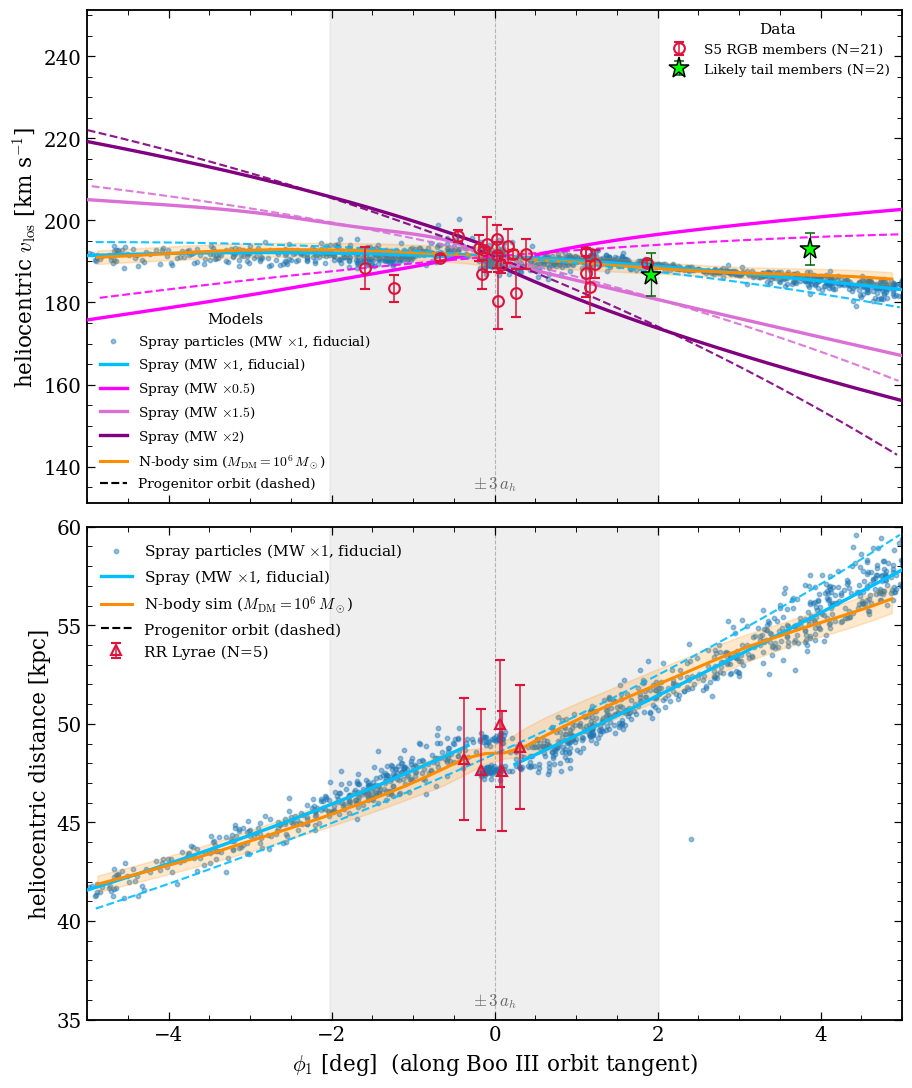

In [14]:
# === Stream observables vs phi1 (Figure 8) ===
import pickle, warnings
from galpy.df import fardal15spraydf
from galpy.util import galpyWarning
from galpy.potential import (
    ChandrasekharDynamicalFrictionForce, HernquistPotential,
    MovingObjectPotential, NonInertialFrameForce,
    evaluateRforces, evaluatephitorques, evaluatezforces,
)
warnings.filterwarnings("ignore", category=galpyWarning)

# Boo III systemic from NB1's GMM (same anchor as the spray pkls)
gmm = pd.read_hdf(OUT_DIR / "boo3_gmm_samples.h5", key="samples")
PMRA_S  = float(gmm["pmr_0"].median())
PMDEC_S = float(gmm["pmd_0"].median())
VHEL_S  = float(gmm["vhel_0"].median())
PARAMS_6D = [RA_BOO3, DEC_BOO3, DIST_KPC, PMRA_S, PMDEC_S, VHEL_S]

pm_norm = np.hypot(PMRA_S, PMDEC_S)
u_phi1_pm = np.array([PMRA_S, PMDEC_S]) / pm_norm   # apparent-PM direction (kept for reference)

# phi_1 axis is along the ORBIT-TANGENT direction at the present-day,
# computed from a fiducial McMillan17 + LMC orbit integration (matches the
# orbit used elsewhere in the paper).  See Section 5 for the orbit definition.
_pot_fid_phi1, _ = _build_lmc_potential(1.0)
_phys = get_physical(_McMillan17); _ro_ph, _vo_ph = _phys["ro"], _phys["vo"]
_ts_b = -np.linspace(0, 0.5, 1001) * u.Gyr
_ts_f =  np.linspace(0, 0.5, 1001) * u.Gyr
_ob_ph = Orbit(PARAMS_6D, radec=True, solarmotion=SOLAR_MOTION, ro=_ro_ph, vo=_vo_ph)
_of_ph = Orbit(PARAMS_6D, radec=True, solarmotion=SOLAR_MOTION, ro=_ro_ph, vo=_vo_ph)
_ob_ph.integrate(_ts_b, _pot_fid_phi1); _of_ph.integrate(_ts_f, _pot_fid_phi1)
_ra_ph  = np.concatenate([np.asarray(_ob_ph.ra(_ts_b))[::-1],  np.asarray(_of_ph.ra(_ts_f))])
_dec_ph = np.concatenate([np.asarray(_ob_ph.dec(_ts_b))[::-1], np.asarray(_of_ph.dec(_ts_f))])
_mid = len(_ra_ph) // 2
_dra_t  = (_ra_ph[_mid+1] - _ra_ph[_mid-1]) * np.cos(np.radians(_dec_ph[_mid]))
_ddec_t = (_dec_ph[_mid+1] - _dec_ph[_mid-1])
_n = np.hypot(_dra_t, _ddec_t)
u_phi1 = np.array([_dra_t / _n, _ddec_t / _n])
u_phi2 = np.array([-u_phi1[1], u_phi1[0]])
PA_PHI1_ORB = float(np.degrees(np.arctan2(u_phi1[0], u_phi1[1])) % 360.0)
print(f"phi_1 axis = orbit tangent  (PA = {PA_PHI1_ORB:.2f} deg E of N)")
print(f"             apparent PM   (PA = {float(np.degrees(np.arctan2(u_phi1_pm[0], u_phi1_pm[1])) % 360.0):.2f} deg, for reference)")
AH_DEG = RHALF_MAJOR_DEG   # 40.34/60 = 0.672 deg
AH3 = 3 * AH_DEG           # 3 a_h = 2.02 deg


def _add_delta(ra, dec):
    ra = np.asarray(ra) % 360
    ra0r, dec0r = np.radians(RA_BOO3), np.radians(DEC_BOO3)
    rar, decr = np.radians(ra), np.radians(dec)
    dra = np.degrees(np.cos(decr) * np.sin(rar - ra0r))
    ddec = np.degrees(np.sin(decr) * np.cos(dec0r)
                      - np.cos(decr) * np.sin(dec0r) * np.cos(rar - ra0r))
    return dra, ddec


def _stream_phi1(dra, ddec):
    return dra * u_phi1[0] + ddec * u_phi1[1]


def _build_lmc_potential(mw_factor, solar_motion=SOLAR_MOTION):
    base = [pp for pp in _McMillan17]
    base[1] = base[1] * mw_factor
    mass_lmc = 1.38e11
    rscale = 16.09
    rhm = rscale * (1 + np.sqrt(2))
    orb_lmc = Orbit.from_name("LMC", solarmotion=solar_motion,
                              **get_physical(base))
    cdf = ChandrasekharDynamicalFrictionForce(
        GMs=mass_lmc * u.Msun, rhm=rhm * u.kpc, dens=base[1],
        **get_physical(base))
    ts = np.linspace(0, 5, 1001) * u.Gyr
    orb_lmc.integrate(-ts, base + [cdf])
    lmcpot = HernquistPotential(amp=2 * mass_lmc * u.Msun, a=rscale * u.kpc,
                                **get_physical(base))
    moving = MovingObjectPotential(orb_lmc, pot=lmcpot, **get_physical(base))
    loc = 1e-4
    axf = lambda t: evaluateRforces(moving, loc, 0., phi=0., t=t, use_physical=False)
    ayf = lambda t: evaluatephitorques(moving, loc, 0., phi=0., t=t, use_physical=False) / loc
    azf = lambda t: evaluatezforces(moving, loc, 0., phi=0., t=t, use_physical=False)
    ti = orb_lmc.time(use_physical=False)[::-1]
    aa = np.array([axf(t) for t in ti])
    ab = np.array([ayf(t) for t in ti])
    ac = np.array([azf(t) for t in ti])
    nip = NonInertialFrameForce(a0=[
        lambda t: np.interp(t, ti, aa),
        lambda t: np.interp(t, ti, ab),
        lambda t: np.interp(t, ti, ac),
    ])
    return base + [nip, moving], base


def _evaluate_arm(arm):
    tp = arm.tp_grid()
    return dict(tp=np.asarray(tp),
                ra=np.asarray(arm.ra(tp)), dec=np.asarray(arm.dec(tp)),
                vlos=np.asarray(arm.vlos(tp)), dist=np.asarray(arm.dist(tp)))


def _contiguous_in_window(tp, x, xlo, xhi):
    in_win = (x >= xlo) & (x <= xhi)
    if not in_win.any():
        return np.zeros_like(in_win)
    i0 = int(np.argmin(np.abs(tp)))
    if not in_win[i0]:
        idx = np.flatnonzero(np.diff(np.concatenate([[0], in_win.astype(int), [0]])))
        runs = idx.reshape(-1, 2)
        if runs.size == 0:
            return np.zeros_like(in_win)
        s, e = runs[np.argmax(runs[:, 1] - runs[:, 0])]
        m = np.zeros_like(in_win); m[s:e] = True
        return m
    i_lo, i_hi = i0, i0
    while i_lo > 0 and in_win[i_lo - 1]:
        i_lo -= 1
    while i_hi < len(tp) - 1 and in_win[i_hi + 1]:
        i_hi += 1
    m = np.zeros_like(in_win); m[i_lo:i_hi + 1] = True
    return m


# ---- 1e6 N-body (already loaded earlier as `sim_*` arrays in cell 17;
#      but we re-load here so this cell is self-contained) ----
with h5py.File(SIM_PATH, "r") as h:
    nb_ra,  nb_dec  = h["ra"][:],  h["dec"][:]
    nb_vlsr, nb_dist = h["vhel"][:], h["dist"][:]   # new sim uses "vhel"
    nb_pmra  = h["pmra"][:]  if "pmra"  in h else None
    nb_pmdec = h["pmdec"][:] if "pmdec" in h else None
# Wrap RA into (RA_BOO3 - 180, RA_BOO3 + 180]; new sim stores raw [-180, 180]
nb_ra = ((nb_ra - RA_BOO3 + 180) % 360) - 180 + RA_BOO3

nb_dra, nb_ddec = _add_delta(nb_ra, nb_dec)
nb_phi1 = _stream_phi1(nb_dra, nb_ddec)


# ---- 3 spray pkls + streamTrack ----
SPRAY_DIR = OUT_DIR / "spray_cache_new6D"   # new6D-built pkls (matches the orbit tangent computed above)
phys = get_physical(_McMillan17); ro, vo = phys["ro"], phys["vo"]
SPRAY = {}
_SPRAY_TODO = [("fid", 1.0), ("mw05", 0.5), ("mw15", 1.5), ("mw2", 2.0)]
_missing = [k for k, _ in _SPRAY_TODO if not (SPRAY_DIR / f"spray_{k}.pkl").exists()]
if _missing:
    print(f"  WARNING: missing new6D spray pkls: {_missing}")
    print(f"  (will be filled by 02_compute_spray.py all -- skipping for this render)")
for key, mw_f in _SPRAY_TODO:
    if not (SPRAY_DIR / f"spray_{key}.pkl").exists():
        continue
    with open(SPRAY_DIR / f"spray_{key}.pkl", "rb") as f:
        c = pickle.load(f)
    pot_v, rtpot_v = _build_lmc_potential(mw_f)
    orb_b3 = Orbit(PARAMS_6D, radec=True, solarmotion=SOLAR_MOTION, ro=ro, vo=vo)
    spdf_v = fardal15spraydf(progenitor_mass=float(c["prog_mass"]) * u.Msun,
                              progenitor=orb_b3, pot=pot_v,
                              tdisrupt=float(c["tdisrupt"]) * u.Gyr, rtpot=rtpot_v,
                              tail="both", ro=ro, vo=vo)
    tr_v = spdf_v.streamTrack(particles=(c["xv"], c["dt"]),
                              custom_transform=np.eye(3),
                              track_n_dense=1001, smoothing_factor=4.0,
                              track_time_range=3.0 * u.Gyr)
    L = _evaluate_arm(tr_v.leading); T = _evaluate_arm(tr_v.trailing)
    L_dra, L_ddec = _add_delta(L["ra"], L["dec"])
    T_dra, T_ddec = _add_delta(T["ra"], T["dec"])
    SPRAY[mw_f] = dict(c=c, L=L, T=T,
                       L_phi1=_stream_phi1(L_dra, L_ddec),
                       T_phi1=_stream_phi1(T_dra, T_ddec))
    # --- Progenitor orbit (dashed-line overlay in Fig 8) ---
    _ts_b = -np.linspace(0, 0.5, 501) * u.Gyr
    _ts_f =  np.linspace(0, 0.5, 501) * u.Gyr
    _o_b = Orbit(PARAMS_6D, radec=True, solarmotion=SOLAR_MOTION, ro=ro, vo=vo)
    _o_f = Orbit(PARAMS_6D, radec=True, solarmotion=SOLAR_MOTION, ro=ro, vo=vo)
    _o_b.integrate(_ts_b, pot_v); _o_f.integrate(_ts_f, pot_v)
    _orb_ra   = np.concatenate([np.asarray(_o_b.ra(_ts_b))[::-1],   np.asarray(_o_f.ra(_ts_f))])
    _orb_dec  = np.concatenate([np.asarray(_o_b.dec(_ts_b))[::-1],  np.asarray(_o_f.dec(_ts_f))])
    _orb_vlos = np.concatenate([np.asarray(_o_b.vlos(_ts_b))[::-1], np.asarray(_o_f.vlos(_ts_f))])
    _orb_dist = np.concatenate([np.asarray(_o_b.dist(_ts_b))[::-1], np.asarray(_o_f.dist(_ts_f))])
    _orb_dra, _orb_ddec = _add_delta(_orb_ra, _orb_dec)
    # tp_orbit: parametric time array matching the concatenated orbit arrays
    # (-0.5 Gyr ... 0 ... +0.5 Gyr).  Used by _contiguous_in_window to keep
    # only the segment of the orbit closest to the present-day progenitor,
    # so the dashed line doesn't jump when the orbit wraps in RA over a full
    # period (~1 Gyr for Boo III).
    _tp_orbit = np.concatenate([np.linspace(-0.5, 0.0, 501),
                                 np.linspace( 0.0, 0.5, 501)])
    SPRAY[mw_f]["orbit"] = dict(tp=_tp_orbit,
                                phi1=_stream_phi1(_orb_dra, _orb_ddec),
                                vlos=_orb_vlos, dist=_orb_dist)
    print(f"  spray {key} (MW x{mw_f}) loaded.")
    # Diagnostic: where do the two arms reach in phi1?
    Lp = SPRAY[mw_f]["L_phi1"]; Tp = SPRAY[mw_f]["T_phi1"]
    Lv = SPRAY[mw_f]["L"]["vlos"]; Tv = SPRAY[mw_f]["T"]["vlos"]
    iLnear = int(np.argmin(np.abs(Lp))); iTnear = int(np.argmin(np.abs(Tp)))
    print(f"     L closest-to-0:  phi1 = {Lp[iLnear]:+6.3f},  vlos = {Lv[iLnear]:+7.2f}")
    print(f"     T closest-to-0:  phi1 = {Tp[iTnear]:+6.3f},  vlos = {Tv[iTnear]:+7.2f}")
    print(f"     L range: phi1 = [{np.nanmin(Lp):+.2f}, {np.nanmax(Lp):+.2f}]")
    print(f"     T range: phi1 = [{np.nanmin(Tp):+.2f}, {np.nanmax(Tp):+.2f}]")


# Fiducial particle scatter
assert 1.0 in SPRAY, "fid spray must be cached for fig 8"
fid = SPRAY[1.0]["c"]["particles"]
fid_dra, fid_ddec = _add_delta(fid["ra"], fid["dec"])
fid_phi1 = _stream_phi1(fid_dra, fid_ddec)
fid_vlos = fid["vlos"]
fid_dist = fid["dist"]  # sprays now at d=48.47 kpc (post-rerun); no manual offset needed


# ---- 21 S5 GMM members ----
gmm_mem = pd.read_csv(OUT_DIR / "boo3_gmm_membership.csv")
gmm_mem = gmm_mem[gmm_mem["p_mem"] > 0.95].copy()
m_dra, m_ddec = _add_delta(gmm_mem["ra"].values, gmm_mem["dec"].values)
gmm_mem["phi1"] = _stream_phi1(m_dra, m_ddec)


# ---- 3 RRL distances (paper default: Garofalo+22 Eq. 19, ZW84 scale) ----
from astropy.io import fits as afits
from astropy import table as atable
from astropy.coordinates import SkyCoord as _SC
FEH_S = -2.34; FEH_S_ERR = 0.11
# Garofalo+22 Eq. 19: M_G = 0.33 [Fe/H] + 1.05 (intrinsic disp. 0.03 mag).
MG_SLOPE, MG_INT = 0.33, 1.05
MG_SLOPE_ERR, MG_INT_ERR = 0.02, 0.03
MG_SIG_INT = 0.03
MG = MG_SLOPE * FEH_S + MG_INT
MG_ERR = np.sqrt((MG_SLOPE_ERR * FEH_S) ** 2
                 + (MG_SLOPE * FEH_S_ERR) ** 2
                 + MG_INT_ERR ** 2
                 + MG_SIG_INT ** 2)
# Load 5-RRL distances from nb01 (auto-generated in output/boo3_rrl_distances.npz)
_rrl_d = np.load(OUT_DIR / "boo3_rrl_distances.npz", allow_pickle=True)
RRL_SIDS = _rrl_d["sids"].tolist()
from astropy.coordinates import SkyCoord as _SC
_rrl_sc = _SC(ra=_rrl_d["ra"]*u.deg, dec=_rrl_d["dec"]*u.deg)
rrl_rows = []
for j, sid in enumerate(RRL_SIDS):
    dra_r, ddec_r = _add_delta(np.array([float(_rrl_d["ra"][j])]),
                                np.array([float(_rrl_d["dec"][j])]))
    rrl_rows.append((int(sid), float(_stream_phi1(dra_r, ddec_r)[0]),
                     float(_rrl_d["d_kpc"][j]), float(_rrl_d["d_err"][j])))
print(f"  Loaded {len(RRL_SIDS)} RRL distances from nb01 (mean d = {_rrl_d['d_mean']:.2f} +/- {_rrl_d['d_mean_err']:.2f} kpc)")


# ---- Two likely tidal-tail RGB members (from figA3 / Sec 5.5) ----
# Same Gaia source IDs as nb01 cell 16's LIKELY_MEMBERS.  They have S5 RV
# but no RR-Lyrae distance, so we add them only to the top (vlos) panel.
LIKELY_TAIL_SIDS = [1451743686723428352, 1445105484053956352]
with afits.open(str(DATA_DIR / "cat_s5_public_dr2.0_beta0.fits")) as h:
    _t_tail = atable.Table(h[1].data)
_t_tail = _t_tail[_t_tail["object_name"] == "Styx"]
tail_rows = []
for sid in LIKELY_TAIL_SIDS:
    row = _t_tail[_t_tail["source_id"] == sid]
    if len(row) == 0: continue
    ra_t  = float(row[0]["ra"]);  dec_t = float(row[0]["dec"])
    v_t   = float(row[0]["vel_calib"]); ve_t = float(row[0]["vel_calib_std"])
    dra_t, ddec_t = _add_delta(np.array([ra_t]), np.array([dec_t]))
    phi1_t = float(_stream_phi1(dra_t, ddec_t)[0])
    tail_rows.append((sid, phi1_t, v_t, ve_t))
print(f"Likely tail RGB members loaded: {len(tail_rows)}")
for sid, p, v, ve in tail_rows:
    print(f"  {sid}: phi1 = {p:+.2f},  vlos = {v:+.2f} +/- {ve:.2f}")


def _running_stats(x, y, edges):
    cen = 0.5 * (edges[1:] + edges[:-1])
    med = np.full(len(cen), np.nan)
    lo = np.full(len(cen), np.nan); hi = np.full(len(cen), np.nan)
    for i in range(len(cen)):
        m = (x >= edges[i]) & (x < edges[i + 1])
        if m.sum() > 5:
            yb = y[m]
            med[i] = np.median(yb)
            lo[i] = np.percentile(yb, 16); hi[i] = np.percentile(yb, 84)
    return cen, med, lo, hi


# ---- 2x1 plot ----
fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(8.4, 10.0), sharex=True)
edges = np.linspace(-5, 5, 41)
SPRAY_COLORS = {1.0: "deepskyblue", 0.5: "magenta", 1.5: "orchid", 2.0: "purple"}
SPRAY_LABELS = {1.0: r"Spray (MW $\times 1$, fiducial)",
                0.5: r"Spray (MW $\times 0.5$)",
                1.5: r"Spray (MW $\times 1.5$)",
                2.0: r"Spray (MW $\times 2$)"}


def _panel(ax, yfield, ylab, ylim, anchor_y, anchor_lbl,
           members_x, members_y, members_yerr, members_lbl, marker,
           sim_y, sim_lbl, mw_factors=(1.0, 0.5, 1.5, 2.0)):
    m_p = (fid_phi1 >= -5) & (fid_phi1 <= 5)
    py = fid_vlos[m_p] if yfield == "vlos" else fid_dist[m_p]
    ax.scatter(fid_phi1[m_p], py, s=8, c="tab:blue", alpha=0.45,
               rasterized=True, zorder=2,
               label=r"Spray particles (MW $\times 1$, fiducial)")
    for mw_f in mw_factors:
        if mw_f not in SPRAY: continue
        s = SPRAY[mw_f]
        Lm = _contiguous_in_window(s["L"]["tp"], s["L_phi1"], -5, 5)
        Tm = _contiguous_in_window(s["T"]["tp"], s["T_phi1"], -5, 5)
        ax.plot(s["L_phi1"][Lm], s["L"][yfield][Lm], "-",
                c=SPRAY_COLORS[mw_f], lw=2.2, zorder=5, label=SPRAY_LABELS[mw_f])
        ax.plot(s["T_phi1"][Tm], s["T"][yfield][Tm], "-",
                c=SPRAY_COLORS[mw_f], lw=2.2, zorder=5)
        # Progenitor orbit (dashed) — keep only the contiguous segment
        # of the orbit closest to the present-day progenitor (tp=0), so the
        # dashed line doesn't jump when the orbit wraps in RA.
        if "orbit" in s:
            om = _contiguous_in_window(s["orbit"]["tp"], s["orbit"]["phi1"], -5, 5)
            o_y = s["orbit"][yfield]
            ax.plot(s["orbit"]["phi1"][om], o_y[om], "--",
                    c=SPRAY_COLORS[mw_f], lw=1.4, alpha=0.9, zorder=6)
    if sim_y is not None:
        m_nb = (nb_phi1 >= -5) & (nb_phi1 <= 5)
        cen, med, lo, hi = _running_stats(nb_phi1[m_nb], sim_y[m_nb], edges)
        ax.fill_between(cen, lo, hi, color="darkorange", alpha=0.20, zorder=3)
        ax.plot(cen, med, "-", c="darkorange", lw=2.0, zorder=5, label=sim_lbl)
    ax.errorbar(members_x, members_y, yerr=members_yerr,
                fmt=marker, ms=7, mfc="none", mec="crimson", mew=1.4,
                ecolor="crimson", lw=1.0, capsize=3, zorder=30,
                label=members_lbl)
    ax.axvline(0, color="0.7", ls="--", lw=0.7, zorder=1)
    ax.axvspan(-AH3, AH3, color="0.85", alpha=0.4, zorder=0)
    ax.text(0, 0.02, r"$\pm\,3\,a_h$", transform=ax.get_xaxis_transform(),
            ha="center", va="bottom", fontsize=11, color="0.4")
    ax.set_ylabel(ylab); ax.set_xlim(-5, 5); ax.set_ylim(*ylim)


_panel(ax_top, "vlos", r"heliocentric $v_{\rm los}$ [km s$^{-1}$]",
       (VHEL_S - 60, VHEL_S + 60),
       VHEL_S, fr"Boötes III ($v_{{\rm hel}} = {VHEL_S:.1f}$ km s$^{{-1}}$)",
       gmm_mem["phi1"].values, gmm_mem["vel_calib"].values,
       gmm_mem["vel_calib_std"].values, f"S5 RGB members (N={len(gmm_mem)})", "o",
       nb_vlsr, r"N-body sim ($M_{\rm DM}=10^{6}\,M_\odot$)")

# Likely tidal-tail RGB members (green stars, top panel only).
if tail_rows:
    _tail_p  = np.array([r[1] for r in tail_rows])
    _tail_v  = np.array([r[2] for r in tail_rows])
    _tail_ve = np.array([r[3] for r in tail_rows])
    ax_top.errorbar(_tail_p, _tail_v, yerr=_tail_ve,
                    fmt="*", ms=14, mfc="lime", mec="k", lw=0.8, capsize=3,
                    ecolor="darkgreen", zorder=35,
                    label=f"Likely tail members (N={len(tail_rows)})")
    ax_top.legend(loc="upper right", fontsize=11)

rrl_x = np.array([r[1] for r in rrl_rows])
rrl_d = np.array([r[2] for r in rrl_rows])
rrl_e = np.array([r[3] for r in rrl_rows])
_panel(ax_bot, "dist", r"heliocentric distance [kpc]", (35, 60),
       DIST_KPC, fr"Boötes III ($D_\odot = {DIST_KPC:.1f}$ kpc)",
       rrl_x, rrl_d, rrl_e, f"RR Lyrae (N={len(rrl_rows)})", "^",
       nb_dist, r"N-body sim ($M_{\rm DM}=10^{6}\,M_\odot$)",
       mw_factors=(1.0,))

ax_bot.set_xlabel(r"$\phi_1$ [deg]  (along Boo III orbit tangent)")
# Two-box legend on the top panel (avoid overlap with the spray curves):
#  - lower-left box: spray + N-body + progenitor orbit (model curves)
#  - lower-right box: S5 members + likely tail members (data points)
# Bottom panel keeps a single legend (less crowded).
from matplotlib.lines import Line2D as _L2D
_proxy_orbit = _L2D([0], [0], ls="--", c="black", lw=1.4,
                    label="Progenitor orbit (dashed)")
def _split_top_legend():
    h, l = ax_top.get_legend_handles_labels()
    # Reorder: place "Progenitor orbit (dashed)" proxy right after the last "Spray" entry
    model_keywords = ("Spray", "N-body")
    model_h, model_l, data_h, data_l = [], [], [], []
    for hi, li in zip(h, l):
        if any(k in li for k in model_keywords):
            model_h.append(hi); model_l.append(li)
        else:
            data_h.append(hi); data_l.append(li)
    # append orbit proxy to model group
    model_h.append(_proxy_orbit); model_l.append(_proxy_orbit.get_label())
    leg1 = ax_top.legend(model_h, model_l, loc="lower left", fontsize=9,
                         framealpha=0.92, title="Models", ncol=1)
    ax_top.add_artist(leg1)
    ax_top.legend(data_h, data_l, loc="upper right", fontsize=9,
                  framealpha=0.92, title="Data")
_split_top_legend()
# Bottom panel: single legend with orbit proxy appended after the spray entries
_h_bot, _l_bot = ax_bot.get_legend_handles_labels()
model_h, model_l, data_h, data_l = [], [], [], []
for hi, li in zip(_h_bot, _l_bot):
    if any(k in li for k in ("Spray", "N-body")):
        model_h.append(hi); model_l.append(li)
    else:
        data_h.append(hi); data_l.append(li)
model_h.append(_proxy_orbit); model_l.append(_proxy_orbit.get_label())
ax_bot.legend(model_h + data_h, model_l + data_l,
              loc="upper left", fontsize=10, framealpha=0.92)
fig.tight_layout()
out_pdf = FIG_DIR / "fig8_phi1_stream.pdf"
fig.savefig(out_pdf, dpi=300, bbox_inches="tight")
print(f"Saved {out_pdf}")
plt.show()


---

**Outputs of this notebook**

| file | content |
|:--|:--|
| `output/boo3_21mem_vgrad_samples.h5`        | 8-parameter v-gradient MCMC posterior |
| `figures/fig7_gradient_comparison.pdf`       | Figure 7 — 2x2 master gradient figure |
